In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import roc_auc_score

training_data= pd.read_csv('../data/cs-training.csv')

X=training_data.drop(columns=['Unnamed: 0','SeriousDlqin2yrs'])
y=training_data['SeriousDlqin2yrs']

#opravim jen ty kody se zbytkem by si mel XGboost poradit ale uvidime

late_cols=['NumberOfTime30-59DaysPastDueNotWorse',
           'NumberOfTimes90DaysLate',
           'NumberOfTime60-89DaysPastDueNotWorse'
           ]

X['special_late_code']=(X[late_cols].isin([96,98]).any(axis=1)).astype(int)

X[late_cols]=X[late_cols].replace([96,98],0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30, stratify=y)

#starting model

xgb_model=XGBClassifier(objective='binary:logistic',
                        eval_metric='auc',
                        random_state=30
                        )

xgb_model.fit(X_train, y_train)

y_test_prob=xgb_model.predict_proba(X_test)[:,1]

auc_score=roc_auc_score(y_test, y_test_prob)

print("AUC score is: ",auc_score)

#feature importance 

feature_importance=pd.DataFrame({'feature':X_train.columns,
                                'importance':xgb_model.feature_importances_ 
                                 })
feature_importance=feature_importance.sort_values('importance',ascending=False)
print(f'\nfeature_importance\n: {feature_importance}')

AUC score is:  0.8573604388742379

feature_importance
:                                  feature  importance
6                NumberOfTimes90DaysLate    0.390406
10                     special_late_code    0.192921
8   NumberOfTime60-89DaysPastDueNotWorse    0.121300
2   NumberOfTime30-59DaysPastDueNotWorse    0.102384
0   RevolvingUtilizationOfUnsecuredLines    0.082658
7           NumberRealEstateLoansOrLines    0.024315
1                                    age    0.018788
5        NumberOfOpenCreditLinesAndLoans    0.018242
3                              DebtRatio    0.017180
4                          MonthlyIncome    0.017041
9                     NumberOfDependents    0.014765


In [5]:
y_train_proba = xgb_model.predict_proba(X_train)[:, 1]
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc) 

Train AUC: 0.9136136798291139
Test AUC: 0.8573604388742379
Gap: 0.05625324095487605


In [6]:
#cap utilization na max 2 

training_data= pd.read_csv('../data/cs-training.csv')

X=training_data.drop(columns=['Unnamed: 0','SeriousDlqin2yrs'])
y=training_data['SeriousDlqin2yrs']


late_cols=['NumberOfTime30-59DaysPastDueNotWorse',
           'NumberOfTimes90DaysLate',
           'NumberOfTime60-89DaysPastDueNotWorse'
           ]

X['special_late_code']=(X[late_cols].isin([96,98]).any(axis=1)).astype(int)

X[late_cols]=X[late_cols].replace([96,98],0)
X['RevolvingUtilizationOfUnsecuredLines'] = X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30, stratify=y)

#model

xgb_model=XGBClassifier(objective='binary:logistic',
                        eval_metric='auc',
                        random_state=30
                        )

xgb_model.fit(X_train, y_train)

y_test_prob=xgb_model.predict_proba(X_test)[:,1]

auc_score=roc_auc_score(y_test, y_test_prob)

print("AUC score is: ",auc_score)

#feature importance 

feature_importance=pd.DataFrame({'feature':X_train.columns,
                                'importance':xgb_model.feature_importances_ 
                                 })
feature_importance=feature_importance.sort_values('importance',ascending=False)
print(f'\nfeature_importance\n: {feature_importance}')

AUC score is:  0.8587436124815663

feature_importance
:                                  feature  importance
6                NumberOfTimes90DaysLate    0.387907
10                     special_late_code    0.219408
8   NumberOfTime60-89DaysPastDueNotWorse    0.110590
2   NumberOfTime30-59DaysPastDueNotWorse    0.096848
0   RevolvingUtilizationOfUnsecuredLines    0.081433
7           NumberRealEstateLoansOrLines    0.023729
1                                    age    0.017443
5        NumberOfOpenCreditLinesAndLoans    0.016773
3                              DebtRatio    0.016291
4                          MonthlyIncome    0.015718
9                     NumberOfDependents    0.013861


In [7]:
# cap utilization na max 2 + oprava DebtRatio při problematickém income
import numpy as np

training_data = pd.read_csv('../data/cs-training.csv')

X = training_data.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
y = training_data['SeriousDlqin2yrs']


late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse'
             ]

X['special_late_code'] = (X[late_cols].isin([96, 98]).any(axis=1)).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)


# cap utilization na 2
X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)


# DebtRatio nedává smysl, pokud MonthlyIncome chybí nebo je 0
bad_income = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
)

X.loc[bad_income, 'DebtRatio'] = np.nan

print('DebtRatio set to NaN:', bad_income.sum())


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30,
    stratify=y
)


# model

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30
)

xgb_model.fit(X_train, y_train)

y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_test_prob)

print("AUC score is: ", auc_score)


# feature importance

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

print(f'\nfeature_importance\n: {feature_importance}')

DebtRatio set to NaN: 31365
AUC score is:  0.8579574460882977

feature_importance
:                                  feature  importance
10                     special_late_code    0.344667
6                NumberOfTimes90DaysLate    0.306233
8   NumberOfTime60-89DaysPastDueNotWorse    0.096140
2   NumberOfTime30-59DaysPastDueNotWorse    0.090323
0   RevolvingUtilizationOfUnsecuredLines    0.072178
7           NumberRealEstateLoansOrLines    0.018345
3                              DebtRatio    0.016090
1                                    age    0.015729
4                          MonthlyIncome    0.014566
5        NumberOfOpenCreditLinesAndLoans    0.014231
9                     NumberOfDependents    0.011498


In [8]:
# cap utilization na max 2 + oprava income / DebtRatio, pridani sloupce pro problemovy income 

training_data = pd.read_csv('../data/cs-training.csv')

X = training_data.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
y = training_data['SeriousDlqin2yrs']


late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse'
             ]

X['special_late_code'] = (X[late_cols].isin([96, 98]).any(axis=1)).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)


# utilization cap na 2
X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)


# age = 0 je neplatná hodnota
X['age'] = X['age'].replace(0, np.nan)

# feature pro income problem bude 0 nebo NaN
X['IncomeProblem'] = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
).astype(int)

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30,
    stratify=y
)


# problematický income = NaN nebo 0
train_bad_income = (
    X_train['MonthlyIncome'].isna()
    | (X_train['MonthlyIncome'] == 0)
)

test_bad_income = (
    X_test['MonthlyIncome'].isna()
    | (X_test['MonthlyIncome'] == 0)
)


# medián pouze z normálních income v TRAINU
median_income = X_train.loc[
    X_train['MonthlyIncome'] > 0,
    'MonthlyIncome'
].median()

print('Median income:', median_income)
print('Bad income train:', train_bad_income.sum())
print('Bad income test:', test_bad_income.sum())


# přepočet DebtRatio pouze u problematického income
X_train.loc[train_bad_income, 'DebtRatio'] = (
    X_train.loc[train_bad_income, 'DebtRatio'] / median_income
)

X_test.loc[test_bad_income, 'DebtRatio'] = (
    X_test.loc[test_bad_income, 'DebtRatio'] / median_income
)


# MonthlyIncome NaN / 0 -> train median
X_train.loc[train_bad_income, 'MonthlyIncome'] = median_income
X_test.loc[test_bad_income, 'MonthlyIncome'] = median_income


# model

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30
)

xgb_model.fit(X_train, y_train)

y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_test_prob)

print("AUC score is: ", auc_score)


# feature importance

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

print(f'\nfeature_importance\n: {feature_importance}')

Median income: 5441.0
Bad income train: 25080
Bad income test: 6285
AUC score is:  0.8587923921220346

feature_importance
:                                  feature  importance
6                NumberOfTimes90DaysLate    0.374226
10                     special_late_code    0.219146
8   NumberOfTime60-89DaysPastDueNotWorse    0.113139
2   NumberOfTime30-59DaysPastDueNotWorse    0.098347
0   RevolvingUtilizationOfUnsecuredLines    0.077877
7           NumberRealEstateLoansOrLines    0.020271
3                              DebtRatio    0.017404
1                                    age    0.017379
5        NumberOfOpenCreditLinesAndLoans    0.016625
4                          MonthlyIncome    0.015969
11                         IncomeProblem    0.015840
9                     NumberOfDependents    0.013777


In [9]:
# XGBoost:
# - special late codes 96/98 -> 0 + special_late_code
# - utilization cap na 2
# - age 0 -> NaN
# - IncomeProblem pro MonthlyIncome NaN / 0
# - MonthlyIncome NaN / 0 -> median z trainu
# - DebtRatio necháváme původní


training_data = pd.read_csv('../data/cs-training.csv')

X = training_data.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
y = training_data['SeriousDlqin2yrs']


# special late codes

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

X['special_late_code'] = (
    X[late_cols].isin([96, 98]).any(axis=1)
).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)


# cap utilization na max 2

X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)


# age 0 je neplatná hodnota

X['age'] = X['age'].replace(0, np.nan)


# indicator pro problematický income

X['IncomeProblem'] = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
).astype(int)


# train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30,
    stratify=y
)


# problematický income v train/test

train_bad_income = (
    X_train['MonthlyIncome'].isna()
    | (X_train['MonthlyIncome'] == 0)
)

test_bad_income = (
    X_test['MonthlyIncome'].isna()
    | (X_test['MonthlyIncome'] == 0)
)


# median income pouze z normálních hodnot v TRAINU

median_income = X_train.loc[
    X_train['MonthlyIncome'] > 0,
    'MonthlyIncome'
].median()

print('Median income:', median_income)
print('Bad income train:', train_bad_income.sum())
print('Bad income test:', test_bad_income.sum())


# doplnění MonthlyIncome mediánem
# DebtRatio se NEMĚNÍ

X_train.loc[train_bad_income, 'MonthlyIncome'] = median_income
X_test.loc[test_bad_income, 'MonthlyIncome'] = median_income


# model

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30
)

xgb_model.fit(X_train, y_train)


# AUC

y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_test_prob)

print("AUC score is: ", auc_score)


# feature importance

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'importance',
    ascending=False
)

print(f'\nfeature_importance\n: {feature_importance}')

Median income: 5441.0
Bad income train: 25080
Bad income test: 6285
AUC score is:  0.8583566890952651

feature_importance
:                                  feature  importance
6                NumberOfTimes90DaysLate    0.349330
10                     special_late_code    0.269419
8   NumberOfTime60-89DaysPastDueNotWorse    0.112661
2   NumberOfTime30-59DaysPastDueNotWorse    0.086021
0   RevolvingUtilizationOfUnsecuredLines    0.070000
7           NumberRealEstateLoansOrLines    0.022313
1                                    age    0.016447
5        NumberOfOpenCreditLinesAndLoans    0.015895
3                              DebtRatio    0.015657
4                          MonthlyIncome    0.015149
11                         IncomeProblem    0.013682
9                     NumberOfDependents    0.013427


**Aktualni nejlepsi preprocesing pro XGboost:**
96/98 → 0 + special_late_code
RevolvingUtilization → cap 2
age 0 → NaN
MonthlyIncome → raw
IncomeProblem → 1 pro NaN nebo 0
DebtRatio → raw
NumberOfDependents → raw
zbytek taky raw
bez scaleru
bez imputace

Optimalizace a overfitting

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30
)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.02, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5, 6],
    'min_child_weight': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    random_state=30,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best CV AUC:", random_search.best_score_)
print("Best parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [ ]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

xgb_local = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    # zatím fixujeme nejlepší hodnoty z random search
    n_estimators=200,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7
)

param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_child_weight': [3, 5, 10, 15, 20]
}

grid_search = GridSearchCV(
    estimator=xgb_local,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best CV AUC:", grid_search.best_score_)
print("Best parameters:", grid_search.best_params_)


# results dataframe
results = pd.DataFrame(grid_search.cv_results_)


# heatmap data
heatmap_data = results.pivot(
    index='param_min_child_weight',
    columns='param_max_depth',
    values='mean_test_score'
)

print("\nCV AUC heatmap data:")
print(heatmap_data)


# heatmap
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    heatmap_data.values,
    aspect='auto'
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel('max_depth')
ax.set_ylabel('min_child_weight')
ax.set_title('5-fold CV ROC-AUC')

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(
            j,
            i,
            f'{heatmap_data.iloc[i, j]:.5f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# nejlepší model na našem X_test
best_xgb = grid_search.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

In [ ]:
# regularization grid: gamma x reg_lambda

xgb_reg = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    # nejlepší hodnoty z předchozího gridu
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.7
)

param_grid = {
    'gamma': [0, 0.1, 0.25, 0.5, 1, 2],
    'reg_lambda': [0.5, 1, 2, 5, 10, 20]
}

grid_reg = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_reg.fit(X_train, y_train)


print("Best CV AUC:", grid_reg.best_score_)
print("Best parameters:", grid_reg.best_params_)


# výsledky
results = pd.DataFrame(grid_reg.cv_results_)

results['gap'] = (
    results['mean_train_score']
    - results['mean_test_score']
)


# -------------------------
# CV AUC heatmap
# -------------------------

auc_heatmap = results.pivot(
    index='param_reg_lambda',
    columns='param_gamma',
    values='mean_test_score'
)

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    auc_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(auc_heatmap.columns)))
ax.set_xticklabels(auc_heatmap.columns)

ax.set_yticks(range(len(auc_heatmap.index)))
ax.set_yticklabels(auc_heatmap.index)

ax.set_xlabel('gamma')
ax.set_ylabel('reg_lambda')
ax.set_title('5-fold CV ROC-AUC')

for i in range(len(auc_heatmap.index)):
    for j in range(len(auc_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{auc_heatmap.iloc[i, j]:.5f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# Train - CV gap heatmap
# -------------------------

gap_heatmap = results.pivot(
    index='param_reg_lambda',
    columns='param_gamma',
    values='gap'
)

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    gap_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(gap_heatmap.columns)))
ax.set_xticklabels(gap_heatmap.columns)

ax.set_yticks(range(len(gap_heatmap.index)))
ax.set_yticklabels(gap_heatmap.index)

ax.set_xlabel('gamma')
ax.set_ylabel('reg_lambda')
ax.set_title('Train - CV AUC Gap')

for i in range(len(gap_heatmap.index)):
    for j in range(len(gap_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{gap_heatmap.iloc[i, j]:.4f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# nejlepší model na X_test
# -------------------------

best_xgb = grid_reg.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

In [ ]:
# L1 regularization grid

xgb_alpha = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5
)

param_grid = {
    'reg_alpha': [0, 0.01, 0.05, 0.1, 0.25, 0.5, 1, 2, 5]
}

grid_alpha = GridSearchCV(
    estimator=xgb_alpha,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_alpha.fit(X_train, y_train)

print("Best CV AUC:", grid_alpha.best_score_)
print("Best parameters:", grid_alpha.best_params_)


results_alpha = pd.DataFrame(grid_alpha.cv_results_)

results_alpha['gap'] = (
    results_alpha['mean_train_score']
    - results_alpha['mean_test_score']
)

print(
    results_alpha[
        [
            'param_reg_alpha',
            'mean_train_score',
            'mean_test_score',
            'gap'
        ]
    ]
)


# nejlepší model na X_test

best_xgb = grid_alpha.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

In [ ]:
# learning_rate x n_estimators grid

xgb_lr = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    max_depth=5,
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0
)

param_grid = {
    'learning_rate': [0.01, 0.02, 0.03, 0.04, 0.05, 0.075, 0.10],
    'n_estimators': [100, 200, 300, 400, 600, 800, 1000]
}

grid_lr = GridSearchCV(
    estimator=xgb_lr,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_lr.fit(X_train, y_train)

print("Best CV AUC:", grid_lr.best_score_)
print("Best parameters:", grid_lr.best_params_)


# results
results = pd.DataFrame(grid_lr.cv_results_)

results['gap'] = (
    results['mean_train_score']
    - results['mean_test_score']
)


# -------------------------
# CV AUC heatmap
# -------------------------

auc_heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_learning_rate',
    values='mean_test_score'
)

# vypis hodnot heatmapy
print("\nCV AUC HEATMAP:")
print(auc_heatmap.round(6).to_string())


fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    auc_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(auc_heatmap.columns)))
ax.set_xticklabels(auc_heatmap.columns)

ax.set_yticks(range(len(auc_heatmap.index)))
ax.set_yticklabels(auc_heatmap.index)

ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
ax.set_title('5-fold CV ROC-AUC')

for i in range(len(auc_heatmap.index)):
    for j in range(len(auc_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{auc_heatmap.iloc[i, j]:.5f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# Train - CV gap heatmap
# -------------------------

gap_heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_learning_rate',
    values='gap'
)

# vypis hodnot heatmapy
print("\nTRAIN - CV GAP HEATMAP:")
print(gap_heatmap.round(6).to_string())


fig, ax = plt.subplots(figsize=(10, 7))

im = ax.imshow(
    gap_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(gap_heatmap.columns)))
ax.set_xticklabels(gap_heatmap.columns)

ax.set_yticks(range(len(gap_heatmap.index)))
ax.set_yticklabels(gap_heatmap.index)

ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
ax.set_title('Train - CV AUC Gap')

for i in range(len(gap_heatmap.index)):
    for j in range(len(gap_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{gap_heatmap.iloc[i, j]:.4f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# nejlepší model na X_test
# -------------------------

best_xgb = grid_lr.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

In [ ]:
# local learning_rate x n_estimators grid

xgb_lr_local = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    max_depth=5,
    min_child_weight=15,
    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0
)

param_grid = {
    'learning_rate': [0.005, 0.0075, 0.01, 0.0125, 0.015],
    'n_estimators': [800, 1000, 1200, 1500, 2000]
}

grid_lr_local = GridSearchCV(
    estimator=xgb_lr_local,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_lr_local.fit(X_train, y_train)

print("Best CV AUC:", grid_lr_local.best_score_)
print("Best parameters:", grid_lr_local.best_params_)


# results
results = pd.DataFrame(grid_lr_local.cv_results_)

results['gap'] = (
    results['mean_train_score']
    - results['mean_test_score']
)


# -------------------------
# CV AUC heatmap
# -------------------------

auc_heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_learning_rate',
    values='mean_test_score'
)

print("\nCV AUC HEATMAP:")
print(auc_heatmap.round(6).to_string())


fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    auc_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(auc_heatmap.columns)))
ax.set_xticklabels(auc_heatmap.columns)

ax.set_yticks(range(len(auc_heatmap.index)))
ax.set_yticklabels(auc_heatmap.index)

ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
ax.set_title('5-fold CV ROC-AUC')

for i in range(len(auc_heatmap.index)):
    for j in range(len(auc_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{auc_heatmap.iloc[i, j]:.6f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# Train - CV gap heatmap
# -------------------------

gap_heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_learning_rate',
    values='gap'
)

print("\nTRAIN - CV GAP HEATMAP:")
print(gap_heatmap.round(6).to_string())


fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(
    gap_heatmap.values,
    aspect='auto'
)

ax.set_xticks(range(len(gap_heatmap.columns)))
ax.set_xticklabels(gap_heatmap.columns)

ax.set_yticks(range(len(gap_heatmap.index)))
ax.set_yticklabels(gap_heatmap.index)

ax.set_xlabel('learning_rate')
ax.set_ylabel('n_estimators')
ax.set_title('Train - CV AUC Gap')

for i in range(len(gap_heatmap.index)):
    for j in range(len(gap_heatmap.columns)):
        ax.text(
            j,
            i,
            f'{gap_heatmap.iloc[i, j]:.4f}',
            ha='center',
            va='center'
        )

plt.colorbar(im, ax=ax)
plt.show()


# -------------------------
# nejlepší model na X_test
# -------------------------

best_xgb = grid_lr_local.best_estimator_

y_train_prob = best_xgb.predict_proba(X_train)[:, 1]
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("\nTrain AUC:", train_auc)
print("Test AUC:", test_auc)
print("Gap:", train_auc - test_auc)

Zatim nejlepsi parametry modelu:

In [ ]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    max_depth=5,
    min_child_weight=15,

    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0,

    learning_rate=0.01,
    n_estimators=1000
)

Predikce pro kaggle test dataset

In [ ]:
# FINAL XGBOOST -> KAGGLE SUBMISSION


# 1. Load data

training_data = pd.read_csv('../data/cs-training.csv')
kaggle_test = pd.read_csv('../data/cs-test.csv')
sample_submission = pd.read_csv('../data/sampleEntry.csv')


# 2. Features + target

X = training_data.drop(
    columns=['Unnamed: 0', 'SeriousDlqin2yrs'],
    errors='ignore'
)

y = training_data['SeriousDlqin2yrs']

X_kaggle = kaggle_test.drop(
    columns=['Unnamed: 0', 'SeriousDlqin2yrs'],
    errors='ignore'
)


# 3. Special late codes 96 / 98

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

X['special_late_code'] = (
    X[late_cols].isin([96, 98]).any(axis=1)
).astype(int)

X_kaggle['special_late_code'] = (
    X_kaggle[late_cols].isin([96, 98]).any(axis=1)
).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)
X_kaggle[late_cols] = X_kaggle[late_cols].replace([96, 98], 0)


# 4. Cap RevolvingUtilization na 2

X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)

X_kaggle['RevolvingUtilizationOfUnsecuredLines'] = (
    X_kaggle['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)


# 5. Invalid age = NaN

X['age'] = X['age'].replace(0, np.nan)
X_kaggle['age'] = X_kaggle['age'].replace(0, np.nan)


# 6. Income problem indicator
# MonthlyIncome samotný necháváme RAW

X['IncomeProblem'] = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
).astype(int)

X_kaggle['IncomeProblem'] = (
    X_kaggle['MonthlyIncome'].isna()
    | (X_kaggle['MonthlyIncome'] == 0)
).astype(int)


# kontrola, že train a Kaggle test mají stejné features

print("Train shape:", X.shape)
print("Kaggle test shape:", X_kaggle.shape)

print(
    "Same columns:",
    list(X.columns) == list(X_kaggle.columns)
)


# 7. Finální XGBoost

xgb_final = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    max_depth=5,
    min_child_weight=15,

    subsample=0.7,
    colsample_bytree=0.7,

    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0,

    learning_rate=0.01,
    n_estimators=1000
)


# 8. Train na CELÉM training datasetu

xgb_final.fit(X, y)


# 9. Predikce Kaggle test setu

kaggle_prob = xgb_final.predict_proba(X_kaggle)[:, 1]


# 10. Submission podle Kaggle sampleEntry.csv

submission = sample_submission.copy()

# první sloupec necháme tak, jak ho Kaggle dodal (ID)
# do druhého dáme naše pravděpodobnosti
submission.iloc[:, 1] = kaggle_prob


# 11. Save

submission.to_csv(
    '../data/submission_xgb.csv',
    index=False
)

print("\nSubmission preview:")
print(submission.head())

print("\nRows:", len(submission))
print("Probability min:", kaggle_prob.min())
print("Probability max:", kaggle_prob.max())

print("\nSaved as: ../data/submission_xgb.csv")

Na Kaggle test setu dosáhl finální XGBoost model Private Score 0,86816 a Public Score 0,86189. Private score je pro srovnání s finálním pořadím soutěže důležitější, protože leaderboard se hodnotil podle neveřejné části testovacích dat. Výsledek je tak velmi blízko historickým vítězným řešením kolem 0,8695 AUC, tedy přibližně jen 0,0014 AUC za vítězným skóre. Zároveň dobře navazuje na interní 5-fold CV kolem 0,8663, takže model působí stabilně i mimo vlastní validační split.

On the Kaggle test set, the final XGBoost model achieved a Private Score of 0.86816 and a Public Score of 0.86189. The Private Score is more relevant for comparison with the final competition ranking, as the leaderboard was determined using the hidden portion of the test data. This places the model very close to the historical winning solutions at around 0.8695 AUC, only about 0.0014 AUC behind the top score. The result is also consistent with the internal 5-fold CV score of approximately 0.8663, suggesting that the model generalizes well beyond the validation split.

In [2]:

#searching hyperparametr space


# imports

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from xgboost import XGBClassifier


# load training data

training_data = pd.read_csv('../data/cs-training.csv')

X = training_data.drop(
    columns=['Unnamed: 0', 'SeriousDlqin2yrs'],
    errors='ignore'
)

y = training_data['SeriousDlqin2yrs']


# same feature preparation as above

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

X['special_late_code'] = (
    X[late_cols].isin([96, 98]).any(axis=1)
).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)

X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)

X['age'] = X['age'].replace(0, np.nan)

X['IncomeProblem'] = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
).astype(int)


# train / test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30,
    stratify=y
)


xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,

    # regularization already tuned
    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0,

    # GPU
    tree_method='hist',
    device='cuda'
)


# ---------------------------------------------------------
# LARGE GLOBAL SEARCH SPACE
# ---------------------------------------------------------

param_distributions = {

    'max_depth': [
        2, 3, 4, 5, 6, 7, 8
    ],

    'min_child_weight': [
        1, 2, 3, 5, 7, 10, 12,
        15, 18, 20, 25, 30, 40
    ],

    'subsample': [
        0.55, 0.60, 0.65, 0.70, 0.75,
        0.80, 0.85, 0.90, 0.95, 1.00
    ],

    'colsample_bytree': [
        0.50, 0.55, 0.60, 0.65, 0.70,
        0.75, 0.80, 0.85, 0.90, 0.95, 1.00
    ],

    'learning_rate': [
        0.005, 0.0075,
        0.01, 0.0125, 0.015,
        0.02, 0.025, 0.03,
        0.04, 0.05, 0.075, 0.10
    ],

    'n_estimators': [
        200, 300, 400, 500, 600,
        750, 900, 1000, 1200,
        1500, 1800, 2000, 2500
    ]
}


# ---------------------------------------------------------
# RANDOMIZED SEARCH
# ---------------------------------------------------------

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,

    n_iter=400,
    scoring='roc_auc',
    cv=5,

    random_state=30,

    # One GPU -> do not run many CV fits simultaneously
    n_jobs=1,

    verbose=2,

    # needed so we can inspect overfitting / train-CV gap
    return_train_score=True,

    refit=True
)


random_search.fit(X_train, y_train)


# ---------------------------------------------------------
# BEST MODEL
# ---------------------------------------------------------

best_model = random_search.best_estimator_

y_train_prob = best_model.predict_proba(X_train)[:, 1]
y_test_prob = best_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)


print("\nBEST PARAMETERS:")
print(random_search.best_params_)

print("\nBEST 5-FOLD CV AUC:")
print(random_search.best_score_)

print("\nFINAL PERFORMANCE:")
print("Train AUC:", train_auc)
print("Test AUC: ", test_auc)
print("Gap:      ", train_auc - test_auc)


# ---------------------------------------------------------
# TOP 20 COMBINATIONS
# ---------------------------------------------------------

results = pd.DataFrame(random_search.cv_results_)

results['cv_gap'] = (
    results['mean_train_score'] -
    results['mean_test_score']
)



top20 = results.sort_values(
    'mean_test_score',
    ascending=False
)[[
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'cv_gap',

    'param_max_depth',
    'param_min_child_weight',
    'param_subsample',
    'param_colsample_bytree',
    'param_learning_rate',
    'param_n_estimators'
]].head(20)

print("\nTOP 20:")
display(top20)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
[CV] END colsample_bytree=0.65, learning_rate=0.005, max_depth=5, min_child_weight=15, n_estimators=600, subsample=1.0; total time=   1.3s
[CV] END colsample_bytree=0.65, learning_rate=0.005, max_depth=5, min_child_weight=15, n_estimators=600, subsample=1.0; total time=   1.4s
[CV] END colsample_bytree=0.65, learning_rate=0.005, max_depth=5, min_child_weight=15, n_estimators=600, subsample=1.0; total time=   1.3s
[CV] END colsample_bytree=0.65, learning_rate=0.005, max_depth=5, min_child_weight=15, n_estimators=600, subsample=1.0; total time=   1.3s
[CV] END colsample_bytree=0.65, learning_rate=0.005, max_depth=5, min_child_weight=15, n_estimators=600, subsample=1.0; total time=   1.3s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=3, min_child_weight=15, n_estimators=900, subsample=0.95; total time=   1.3s
[CV] END colsample_bytree=0.7, learning_rate=0.005, max_depth=3, min_child_weight=15, n_estimators=900

,mean_test_score,std_test_score,mean_train_score,cv_gap,param_max_depth,param_min_child_weight,param_subsample,param_colsample_bytree,param_learning_rate,param_n_estimators
322,0.866580,0.003782,0.881868,0.015289,7,7,0.75,0.55,0.0150,300
115,0.866468,0.003741,0.880819,0.014352,6,12,0.60,0.50,0.0050,1800
16,0.866442,0.003866,0.883763,0.017321,8,10,0.55,0.65,0.0125,400
91,0.866429,0.003826,0.888103,0.021673,7,2,0.75,0.60,0.0100,600
137,0.866408,0.003652,0.885753,0.019346,6,2,0.70,0.55,0.0125,750
225,0.866404,0.003818,0.884446,0.018042,6,5,0.65,0.65,0.0100,900
204,0.866383,0.003745,0.878282,0.011899,4,7,0.60,0.90,0.0075,2000
133,0.866375,0.003798,0.876024,0.009649,4,5,0.60,0.90,0.0125,900
378,0.866359,0.003711,0.885403,0.019044,6,1,0.70,0.75,0.0125,600
346,0.866348,0.003833,0.877542,0.011194,5,12,0.70,0.60,0.0100,900


Fitting 5 folds for each of 42 candidates, totalling 210 fits
BEST PARAMETERS:
{'min_child_weight': 15, 'n_estimators': 500}

BEST 5-FOLD CV AUC:
0.8664624083504995

CV AUC HEATMAP:
param_min_child_weight        3         5         7         9         12  \
param_n_estimators                                                         
200                     0.866111  0.866175  0.866113  0.866056  0.866081   
250                     0.866286  0.866359  0.866303  0.866291  0.866306   
300                     0.866308  0.866386  0.866379  0.866301  0.866364   
350                     0.866361  0.866426  0.866429  0.866350  0.866419   
400                     0.866354  0.866407  0.866415  0.866342  0.866408   
500                     0.866305  0.866375  0.866368  0.866327  0.866418   
600                     0.866189  0.866232  0.866179  0.866185  0.866308   

param_min_child_weight        15  
param_n_estimators                
200                     0.866011  
250                     0.86

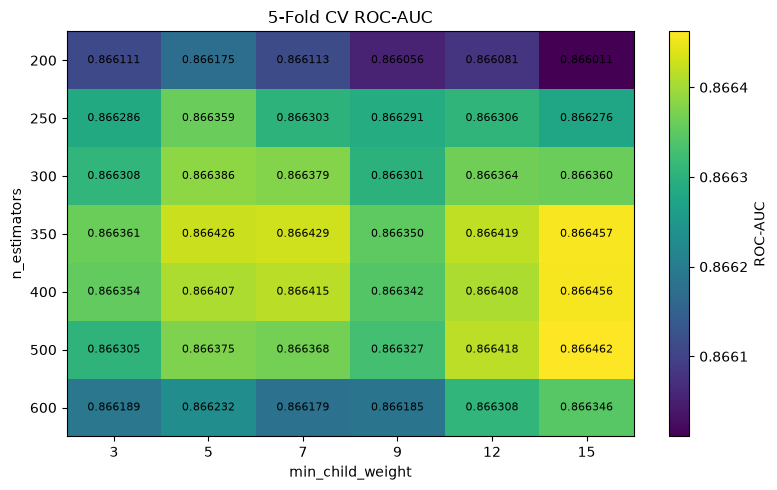

In [3]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load and prepare the training data directly in this cell

training_data = pd.read_csv('../data/cs-training.csv')

X = training_data.drop(
    columns=['Unnamed: 0', 'SeriousDlqin2yrs'],
    errors='ignore'
)

y = training_data['SeriousDlqin2yrs']

late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse'
]

X['special_late_code'] = (
    X[late_cols].isin([96, 98]).any(axis=1)
).astype(int)

X[late_cols] = X[late_cols].replace([96, 98], 0)

X['RevolvingUtilizationOfUnsecuredLines'] = (
    X['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
)

X['age'] = X['age'].replace(0, np.nan)

X['IncomeProblem'] = (
    X['MonthlyIncome'].isna()
    | (X['MonthlyIncome'] == 0)
).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=30,
    stratify=y
)

xgb_local = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    random_state=30,
    max_depth=7,
    subsample=0.75,
    colsample_bytree=0.55,
    learning_rate=0.015,
    gamma=0.5,
    reg_lambda=5,
    reg_alpha=0
)

param_grid = {
    'min_child_weight': [3, 5, 7, 9, 12, 15],
    'n_estimators': [200, 250, 300, 350, 400, 500, 600]
}

grid = GridSearchCV(
    estimator=xgb_local,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid.fit(X_train, y_train)

print("BEST PARAMETERS:")
print(grid.best_params_)

print("\nBEST 5-FOLD CV AUC:")
print(grid.best_score_)

results = pd.DataFrame(grid.cv_results_)

heatmap = results.pivot(
    index='param_n_estimators',
    columns='param_min_child_weight',
    values='mean_test_score'
)

print("\nCV AUC HEATMAP:")
print(heatmap.round(6))

plt.figure(figsize=(8, 5))
plt.imshow(heatmap, aspect='auto')

plt.xticks(
    range(len(heatmap.columns)),
    heatmap.columns
)

plt.yticks(
    range(len(heatmap.index)),
    heatmap.index
)

plt.xlabel('min_child_weight')
plt.ylabel('n_estimators')
plt.title('5-Fold CV ROC-AUC')

for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        plt.text(
            j, i,
            f'{heatmap.iloc[i, j]:.6f}',
            ha='center',
            va='center',
            fontsize=8
        )

plt.colorbar(label='ROC-AUC')
plt.tight_layout()
plt.show()

In [6]:
from sklearn.base import clone

# Load full Kaggle data
train_full = pd.read_csv('../data/cs-training.csv')
test_full = pd.read_csv('../data/cs-test.csv')
sample_submission = pd.read_csv('../data/sampleEntry.csv')

# Target
y_full = train_full['SeriousDlqin2yrs']

# Drop ID + target
X_full = train_full.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
X_kaggle = test_full.drop(
    columns=['Unnamed: 0', 'SeriousDlqin2yrs'],
    errors='ignore'
)

# Same preprocessing for train and Kaggle test
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for df in [X_full, X_kaggle]:

    # Special delinquency codes
    df['special_late_code'] = (
        df[late_cols].isin([96, 98]).any(axis=1)
    ).astype(int)

    df[late_cols] = df[late_cols].replace([96, 98], 0)

    # Utilization cap
    df['RevolvingUtilizationOfUnsecuredLines'] = (
        df['RevolvingUtilizationOfUnsecuredLines'].clip(upper=2)
    )

    # Invalid age
    df['age'] = df['age'].replace(0, np.nan)

    # Income problem indicator
    df['IncomeProblem'] = (
        df['MonthlyIncome'].isna() |
        (df['MonthlyIncome'] == 0)
    ).astype(int)

# Guarantee identical feature names and order
X_kaggle = X_kaggle.reindex(columns=X_full.columns)

print('Same features:', list(X_full.columns) == list(X_kaggle.columns))


# Best model from the GridSearchCV in the previous cell
final_model = clone(grid.best_estimator_)

# Train on all 150k training rows
final_model.fit(X_full, y_full)

# Kaggle probabilities
kaggle_prob = final_model.predict_proba(X_kaggle)[:, 1]

# Submission
submission = sample_submission.copy()
submission['Probability'] = kaggle_prob

submission.to_csv('../data/submission_xgb_global_search.csv', index=False)

print(final_model)
print(submission.head())
print("\nSaved: ../data/submission_xgb_global_search.csv")

Same features: True
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.55, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.015, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=15, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)
   Id  Probability
0   1     0.061528
1   2     0.044223
2   3     0.016665
3   4     0.076541
4   5     0.099770

Saved: ../data/submission_xgb_global_search.csv


PARAMETERS:
{'min_child_weight': 15, 'n_estimators': 500}

PERFORMANCE:
Train AUC: 0.8829749721571112
Test AUC:  0.8668391888647733
Gap:       0.01613578329233789
